In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("/content/drive/MyDrive/Google Colab Dataset/EcommerceData.xlsx")

In [3]:
df.head()

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,unit_price_local,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason
0,DB4F1A096586,order,2024-12-09 00:11:27,CUST0001946,PROD0083,United States,39.8283,-98.5795,NaN,Website,...,36.70,NaN,0.0,0.00,110.10,1.00,110.10,False,NaT,NaN
1,3550A69EEA36,order,2025-08-11 21:31:03,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,19.70,NaN,0.0,9.85,108.35,0.66,71.51,False,NaT,NaN
2,0C3CAE65E90C,order,2025-09-30 15:39:28,CUST0001105,PROD0075,Canada,56.1304,-106.3468,NaN,Website,...,20.12,NaN,0.0,1.01,21.13,1.00,21.13,False,NaT,NaN
3,7DDC83355865,invoice,2024-09-26 04:13:11,CUST0003164,PROD0017,United States,39.8283,-98.5795,NaN,Partner,...,19.00,NaN,0.0,0.00,190.00,1.00,190.00,False,NaT,NaN
4,DAE0B37D8815,order,2024-06-23 16:03:04,CUST0003410,PROD0099,United States,39.8283,-98.5795,NaN,Website,...,29.38,NaN,0.0,0.00,88.14,1.00,88.14,False,NaT,NaN


In [4]:
#pandas
df.isnull().sum()


,0
event_id,0
event_type,0
event_date,0
customer_id,0
product_id,0
country,0
latitude,0
longitude,0
region,19579
channel,0


In [5]:
df[["region","quantity"]]

,region,quantity
0,NaN,3
1,APAC,5
2,NaN,1
3,NaN,10
4,NaN,3
...,...,...
47995,LATAM,10
47996,EU,10
47997,APAC,3
47998,LATAM,3


In [6]:
df.loc[888]

,888
event_id,CFA216CBA4E8
event_type,order
event_date,2024-09-14 00:36:14
customer_id,CUST0001263
product_id,PROD0084
country,Brazil
latitude,-14.235
longitude,-51.9253
region,LATAM
channel,Direct Sales


In [7]:
df["region"].mode()

,region
0,EU


In [8]:
df["region"].mode()[0]

'EU'

In [9]:
df["region"].fillna(df["region"].mode()[0], inplace=True)

/tmp/ipykernel_15595/3134535072.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["region"].fillna(df["region"].mode()[0], inplace=True)


In [10]:
df["region"].isnull().sum()

np.int64(0)

In [11]:
df["discount_code"].mode()

,discount_code
0,WELCOME10


In [12]:
df["discount_code"].mode()[0]

'WELCOME10'

In [13]:
df["discount_code"].fillna(df["discount_code"].mode()[0], inplace=True)

/tmp/ipykernel_15595/2959298993.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["discount_code"].fillna(df["discount_code"].mode()[0], inplace=True)


In [14]:
df["discount_code"].isnull().sum()

np.int64(0)

In [15]:
df["Refunt_Status"]= np.where(df["is_refunded"]== True,"Refunded","successfull")

In [16]:
df.head()

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason,Refunt_Status
0,DB4F1A096586,order,2024-12-09 00:11:27,CUST0001946,PROD0083,United States,39.8283,-98.5795,EU,Website,...,WELCOME10,0.0,0.00,110.10,1.00,110.10,False,NaT,NaN,successfull
1,3550A69EEA36,order,2025-08-11 21:31:03,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,WELCOME10,0.0,9.85,108.35,0.66,71.51,False,NaT,NaN,successfull
2,0C3CAE65E90C,order,2025-09-30 15:39:28,CUST0001105,PROD0075,Canada,56.1304,-106.3468,EU,Website,...,WELCOME10,0.0,1.01,21.13,1.00,21.13,False,NaT,NaN,successfull
3,7DDC83355865,invoice,2024-09-26 04:13:11,CUST0003164,PROD0017,United States,39.8283,-98.5795,EU,Partner,...,WELCOME10,0.0,0.00,190.00,1.00,190.00,False,NaT,NaN,successfull
4,DAE0B37D8815,order,2024-06-23 16:03:04,CUST0003410,PROD0099,United States,39.8283,-98.5795,EU,Website,...,WELCOME10,0.0,0.00,88.14,1.00,88.14,False,NaT,NaN,successfull


In [17]:
df.groupby("Refunt_Status")["is_refunded"].value_counts()

,,count
Refunt_Status,is_refunded,
Refunded,True,1005
successfull,False,46995


In [18]:
df["Revenu_type"]= np.where(df["event_type"]== True, "Renewal","New Sale")

In [19]:
df.head()

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason,Refunt_Status,Revenu_type
0,DB4F1A096586,order,2024-12-09 00:11:27,CUST0001946,PROD0083,United States,39.8283,-98.5795,EU,Website,...,0.0,0.00,110.10,1.00,110.10,False,NaT,NaN,successfull,New Sale
1,3550A69EEA36,order,2025-08-11 21:31:03,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,0.0,9.85,108.35,0.66,71.51,False,NaT,NaN,successfull,New Sale
2,0C3CAE65E90C,order,2025-09-30 15:39:28,CUST0001105,PROD0075,Canada,56.1304,-106.3468,EU,Website,...,0.0,1.01,21.13,1.00,21.13,False,NaT,NaN,successfull,New Sale
3,7DDC83355865,invoice,2024-09-26 04:13:11,CUST0003164,PROD0017,United States,39.8283,-98.5795,EU,Partner,...,0.0,0.00,190.00,1.00,190.00,False,NaT,NaN,successfull,New Sale
4,DAE0B37D8815,order,2024-06-23 16:03:04,CUST0003410,PROD0099,United States,39.8283,-98.5795,EU,Website,...,0.0,0.00,88.14,1.00,88.14,False,NaT,NaN,successfull,New Sale


In [20]:
df.groupby("Revenu_type")["event_type"].value_counts()

Revenu_type  event_type
New Sale     order         33601
             invoice       14399
Name: count, dtype: int64

In [21]:
df["Revenu_type"]= np.where(df["event_type"]== True,"Renewal","New sales")

In [22]:
df.head()

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason,Refunt_Status,Revenu_type
0,DB4F1A096586,order,2024-12-09 00:11:27,CUST0001946,PROD0083,United States,39.8283,-98.5795,EU,Website,...,0.0,0.00,110.10,1.00,110.10,False,NaT,NaN,successfull,New sales
1,3550A69EEA36,order,2025-08-11 21:31:03,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,0.0,9.85,108.35,0.66,71.51,False,NaT,NaN,successfull,New sales
2,0C3CAE65E90C,order,2025-09-30 15:39:28,CUST0001105,PROD0075,Canada,56.1304,-106.3468,EU,Website,...,0.0,1.01,21.13,1.00,21.13,False,NaT,NaN,successfull,New sales
3,7DDC83355865,invoice,2024-09-26 04:13:11,CUST0003164,PROD0017,United States,39.8283,-98.5795,EU,Partner,...,0.0,0.00,190.00,1.00,190.00,False,NaT,NaN,successfull,New sales
4,DAE0B37D8815,order,2024-06-23 16:03:04,CUST0003410,PROD0099,United States,39.8283,-98.5795,EU,Website,...,0.0,0.00,88.14,1.00,88.14,False,NaT,NaN,successfull,New sales


In [23]:
df.groupby("Revenu_type")["event_type"].value_counts()

Revenu_type  event_type
New sales    order         33601
             invoice       14399
Name: count, dtype: int64

In [24]:
#Matplotlib
df.head()

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason,Refunt_Status,Revenu_type
0,DB4F1A096586,order,2024-12-09 00:11:27,CUST0001946,PROD0083,United States,39.8283,-98.5795,EU,Website,...,0.0,0.00,110.10,1.00,110.10,False,NaT,NaN,successfull,New sales
1,3550A69EEA36,order,2025-08-11 21:31:03,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,0.0,9.85,108.35,0.66,71.51,False,NaT,NaN,successfull,New sales
2,0C3CAE65E90C,order,2025-09-30 15:39:28,CUST0001105,PROD0075,Canada,56.1304,-106.3468,EU,Website,...,0.0,1.01,21.13,1.00,21.13,False,NaT,NaN,successfull,New sales
3,7DDC83355865,invoice,2024-09-26 04:13:11,CUST0003164,PROD0017,United States,39.8283,-98.5795,EU,Partner,...,0.0,0.00,190.00,1.00,190.00,False,NaT,NaN,successfull,New sales
4,DAE0B37D8815,order,2024-06-23 16:03:04,CUST0003410,PROD0099,United States,39.8283,-98.5795,EU,Website,...,0.0,0.00,88.14,1.00,88.14,False,NaT,NaN,successfull,New sales


In [25]:
#barchart
ab = df["event_type"].value_counts().reset_index()

In [26]:
ab

,event_type,count
0,order,33601
1,invoice,14399


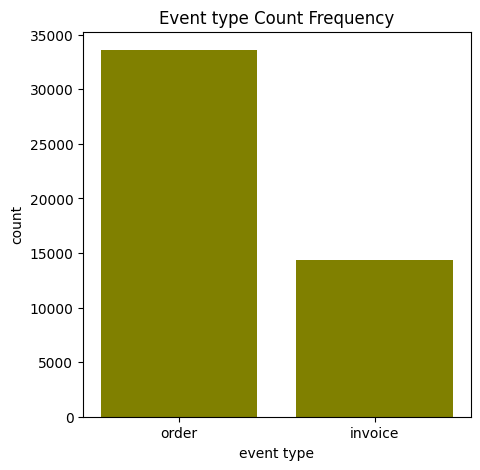

In [110]:
plt.figure(figsize=(5,5))
plt.bar(ab['event_type'], ab['count'], color="olive")
plt.title("Event type Count Frequency")
plt.xlabel("event type")
plt.ylabel("count")
plt.show()

In [53]:
latitude_mean =df.groupby("channel")["latitude"].mean()

In [54]:
latitude_mean

,latitude
channel,
Direct Sales,35.369888
Marketplace,35.648242
Partner,36.306265
Reseller,35.601665
Website,35.336653


In [55]:
latitude_mean.index

Index(['Direct Sales', 'Marketplace', 'Partner', 'Reseller', 'Website'], dtype='object', name='channel')

In [56]:
latitude_mean.values

array([35.36988764, 35.64824186, 36.30626497, 35.60166467, 35.33665278])

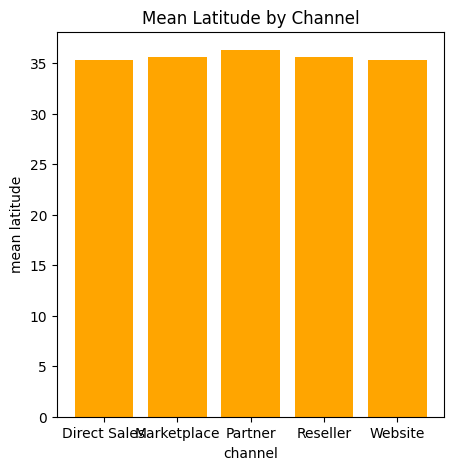

In [111]:
plt.figure(figsize=(5,5))
plt.bar(latitude_mean.index,latitude_mean.values, color="orange")
plt.title("Mean Latitude by Channel")
plt.xlabel("channel")
plt.ylabel("mean latitude")
plt.show()

Text(0, 0.5, 'latitude')

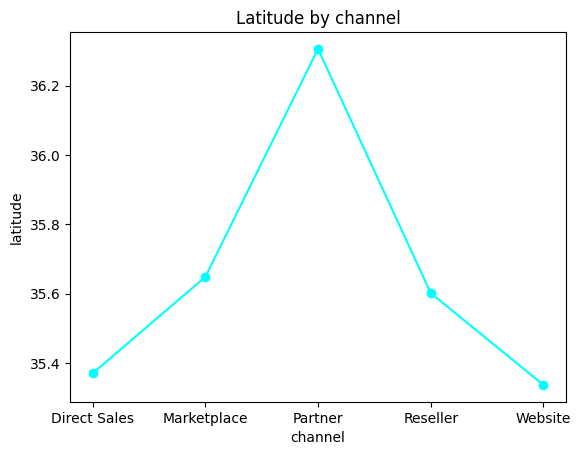

In [125]:
plt.plot(latitude_mean.index,latitude_mean.values, marker="o", color="cyan")
plt.title("Latitude by channel")
plt.xlabel("channel")
plt.ylabel("latitude")

Text(0, 0.5, 'net revenue')

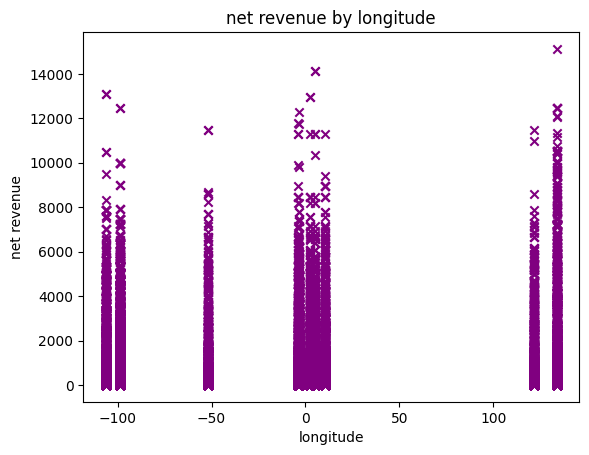

In [109]:
plt.scatter(df["longitude"],df["net_revenue_local"], marker="x",color="purple")
plt.title("net revenue by longitude")
plt.xlabel("longitude")
plt.ylabel("net revenue")

In [74]:
#pie chart
Order_Status = df['Refunt_Status'].value_counts()


In [75]:
Order_Status

,count
Refunt_Status,
successfull,46995
Refunded,1005


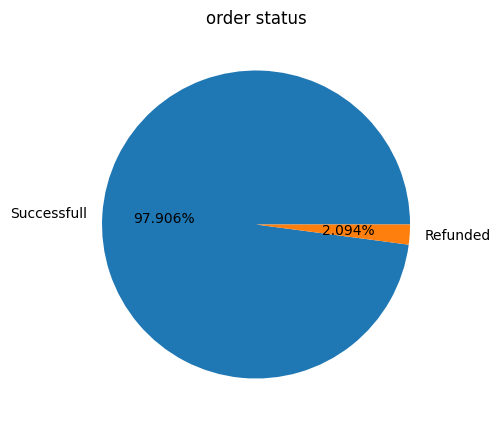

In [86]:
plt.figure(figsize=(5,5))
plt.pie(Order_Status, labels=["Successfull","Refunded"], autopct="%2.3f%%")
plt.title("order status")
plt.show()

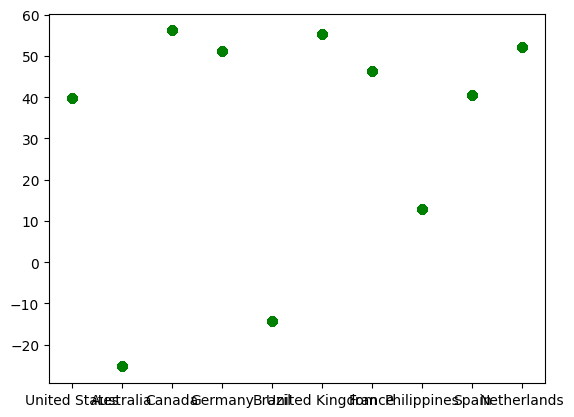

In [123]:
plt.scatter(df["country"],df["latitude"],color="green")

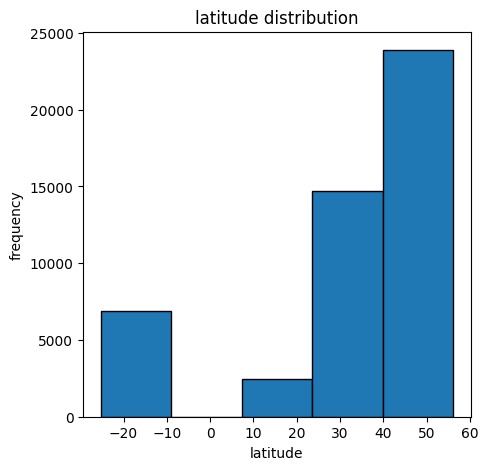

In [105]:
#histogram
plt.figure(figsize=(5,5))
plt.hist(df["latitude"],bins=5,edgecolor="black")
plt.title("latitude distribution")
plt.xlabel("latitude")
plt.ylabel("frequency")
plt.show()

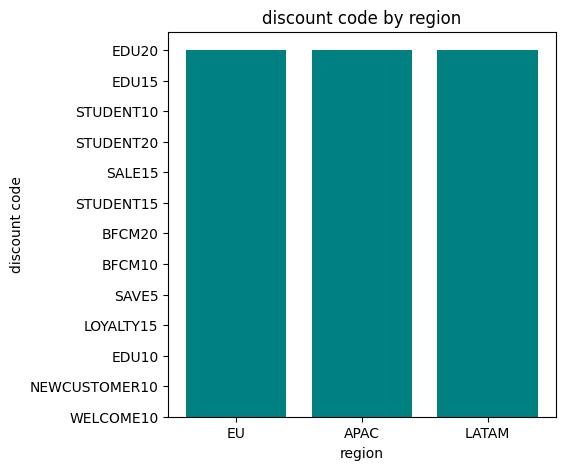

In [108]:
plt.figure(figsize=(5,5))
plt.bar(df["region"],df['discount_code'],color="Teal")
plt.title("discount code by region")
plt.xlabel("region")
plt.ylabel("discount code")
plt.show()

In [126]:
#seabron
df.head()


,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason,Refunt_Status,Revenu_type
0,DB4F1A096586,order,2024-12-09 00:11:27,CUST0001946,PROD0083,United States,39.8283,-98.5795,EU,Website,...,0.0,0.00,110.10,1.00,110.10,False,NaT,NaN,successfull,New sales
1,3550A69EEA36,order,2025-08-11 21:31:03,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,0.0,9.85,108.35,0.66,71.51,False,NaT,NaN,successfull,New sales
2,0C3CAE65E90C,order,2025-09-30 15:39:28,CUST0001105,PROD0075,Canada,56.1304,-106.3468,EU,Website,...,0.0,1.01,21.13,1.00,21.13,False,NaT,NaN,successfull,New sales
3,7DDC83355865,invoice,2024-09-26 04:13:11,CUST0003164,PROD0017,United States,39.8283,-98.5795,EU,Partner,...,0.0,0.00,190.00,1.00,190.00,False,NaT,NaN,successfull,New sales
4,DAE0B37D8815,order,2024-06-23 16:03:04,CUST0003410,PROD0099,United States,39.8283,-98.5795,EU,Website,...,0.0,0.00,88.14,1.00,88.14,False,NaT,NaN,successfull,New sales


<Axes: xlabel='latitude', ylabel='net_revenue_usd'>

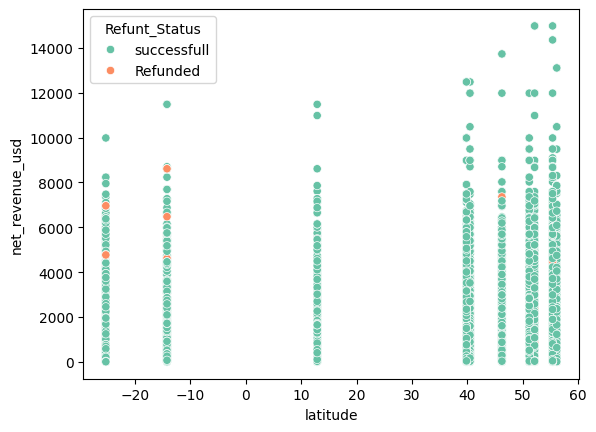

In [140]:
sns.scatterplot(data = df, x="latitude", y="net_revenue_usd", hue="Refunt_Status",palette="Set2")

<Axes: xlabel='latitude', ylabel='event_type'>

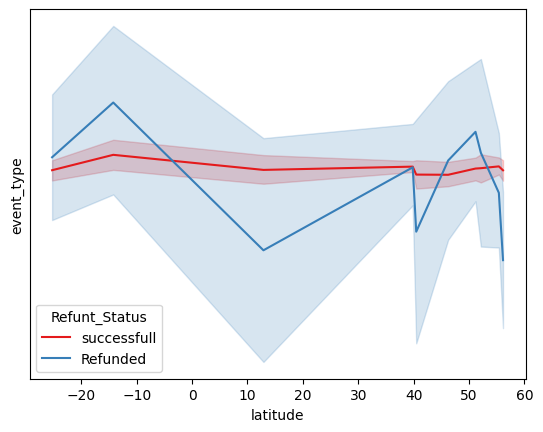

In [139]:
sns.lineplot(data = df, x="latitude",y="event_type", hue="Refunt_Status",palette="Set1")

<Axes: xlabel='channel', ylabel='Count'>

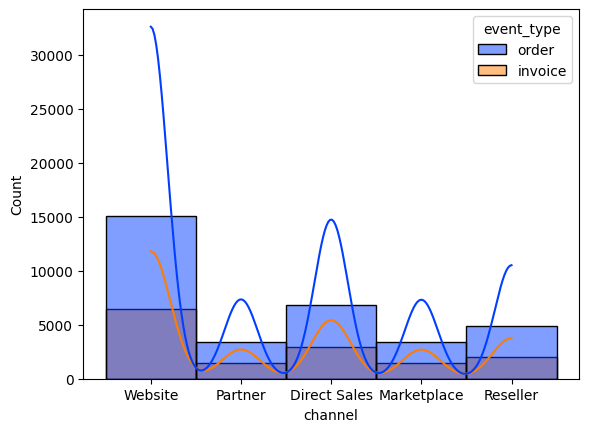

In [146]:
sns.histplot(data= df, x="channel",bins=60,kde=True, hue="event_type",palette="bright")

<Axes: xlabel='latitude', ylabel='Density'>

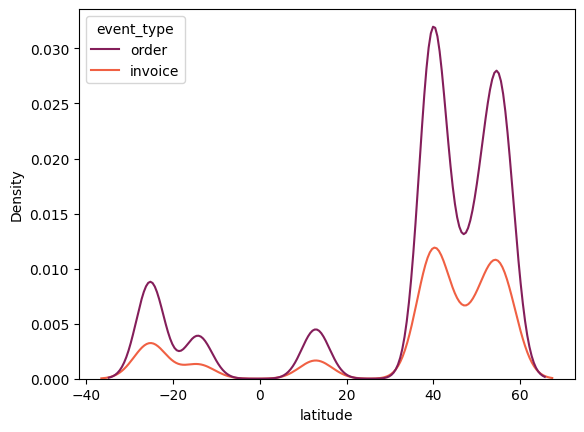

In [147]:
sns.kdeplot(data=df, x="latitude", hue="event_type",palette="rocket")

/tmp/ipykernel_15595/1862545743.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x="region",y="latitude",ci=False, palette="viridis")
/tmp/ipykernel_15595/1862545743.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="region",y="latitude",ci=False, palette="viridis")


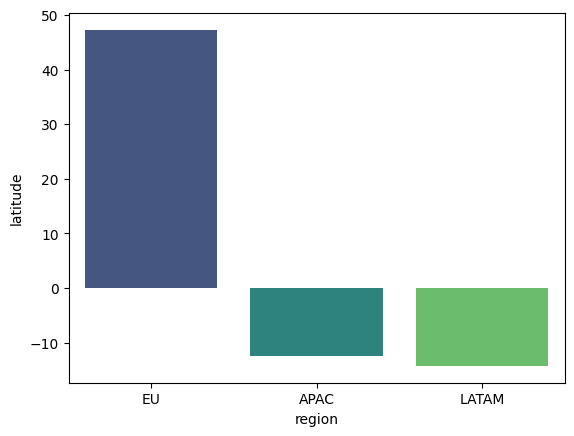

In [150]:
sns.barplot(data=df, x="region",y="latitude",ci=False, palette="viridis")
plt.show()

<Axes: xlabel='tax_local'>

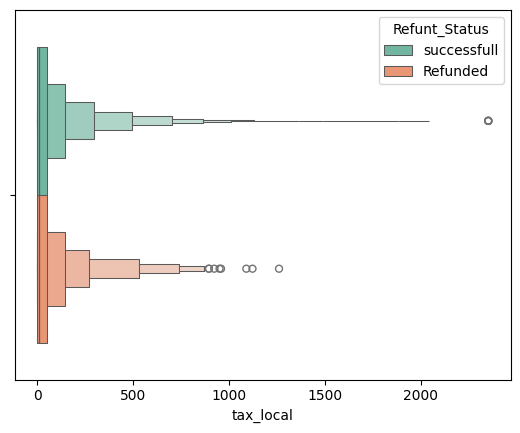

In [154]:
sns.boxenplot(data=df, x="tax_local", hue="Refunt_Status",palette="Set2")

/tmp/ipykernel_15595/2937036412.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x="Refunt_Status",y="latitude",hue="region",ci=False,palette="magma")


<Axes: xlabel='Refunt_Status', ylabel='latitude'>

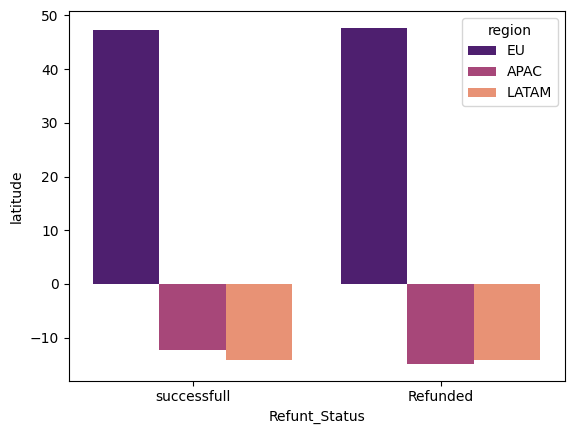

In [160]:
sns.barplot(data=df, x="Refunt_Status",y="latitude",hue="region",ci=False,palette="magma")

In [161]:
#correlation
correlation_matrix = df.corr(numeric_only=True)


In [162]:
correlation_matrix

,latitude,longitude,quantity,unit_price_local,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded
latitude,1.000000,-0.587802,-0.007453,-0.141453,-0.049522,-0.043063,-0.080786,0.814498,0.002347,-0.003110
longitude,-0.587802,1.000000,0.002949,0.088217,0.037704,0.234007,0.075062,-0.388308,0.026613,0.000869
quantity,-0.007453,0.002949,1.000000,-0.019854,0.279851,0.425154,0.550497,-0.009253,0.557165,-0.002601
unit_price_local,-0.141453,0.088217,-0.019854,1.000000,0.284176,0.413421,0.561697,-0.163801,0.537106,0.001123
discount_local,-0.049522,0.037704,0.279851,0.284176,1.000000,0.397989,0.448356,-0.053357,0.433455,0.003292
tax_local,-0.043063,0.234007,0.425154,0.413421,0.397989,1.000000,0.795227,0.040384,0.813056,0.000258
net_revenue_local,-0.080786,0.075062,0.550497,0.561697,0.448356,0.795227,1.000000,-0.084135,0.979860,-0.003246
fx_rate_to_usd,0.814498,-0.388308,-0.009253,-0.163801,-0.053357,0.040384,-0.084135,1.000000,0.012981,-0.003072
net_revenue_usd,0.002347,0.026613,0.557165,0.537106,0.433455,0.813056,0.979860,0.012981,1.000000,-0.003767
is_refunded,-0.003110,0.000869,-0.002601,0.001123,0.003292,0.000258,-0.003246,-0.003072,-0.003767,1.000000


<Axes: >

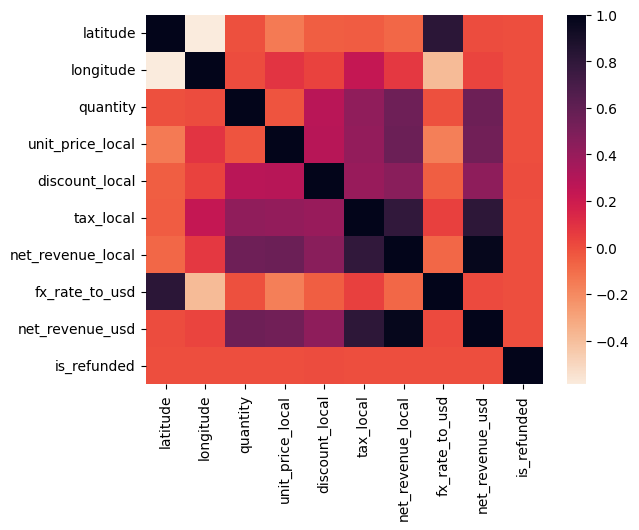

In [166]:
sns.heatmap(data= correlation_matrix, cmap="rocket_r")

/tmp/ipykernel_15595/223104894.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=correlation_matrix,ci=False,palette="dark")


<Axes: >

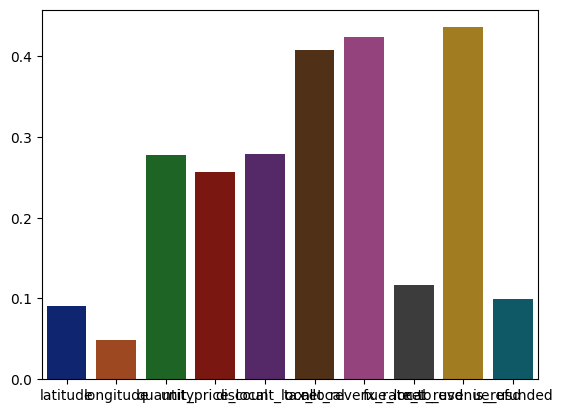

In [168]:
sns.barplot(data=correlation_matrix,ci=False,palette="dark")